# Yield Curve Decomposition: Level, Slope, and Curvature

**Docker image**: `ml4t`

**Chapter 14: Latent Factors**

This notebook demonstrates one of PCA's most celebrated applications:
decomposing the Treasury yield curve into its three primary factors.

**Learning Objectives:**
- Apply PCA to Treasury yield changes and interpret the resulting factors
- Understand why PCA works exceptionally well for yield curves (low-dimensional macro drivers)
- Visualize factor loadings, time series, and reconstruction quality
- Connect the decomposition to practical factor-based hedging

## Where this fits in the framework

Yield-curve PCA is a textbook **Stage 1** decomposition (Figure 14.9):
the cross-section of yields is compressed to three orthogonal factors.
Stage 1 is essentially where the yield curve story ends in this notebook —
the factors are interpretable risk dimensions used for hedging and risk
decomposition, not return forecasts. The two-step framework's Stage 2 +
Stage 3 mechanics become relevant when factors are used predictively;
see [`04_ipca`](04_ipca.ipynb) for that pipeline on equity panels.

**Key Concepts (Litterman & Scheinkman, 1991):**
- PC1 (Level): Parallel shift of the entire curve (~82% of variance in this sample)
- PC2 (Slope): Steepening/flattening — opposite moves at short vs long end (~12%)
- PC3 (Curvature): Butterfly twist — middle moves opposite to ends (~3%)

**Prerequisites**: Complete [`01_pca_equity_sectors`](01_pca_equity_sectors.ipynb); requires FRED macro data.

**Data Source**: FRED macro parquet (canonical data, no API calls). Uses 8
Treasury constant-maturity series (1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 20Y, 30Y) — a
dense enough grid for the classical Level / Slope / Curvature pattern to
emerge clearly, with PC1/PC2/PC3 explaining ~82/12/3 % of the variance in
this 2000–2024 sample.

**Book Reference**: Chapter 14, Section 14.4 (The Yield Curve Decoded)

## 1. Setup and Imports

In [1]:
"""Yield Curve Decomposition — Level, Slope, and Curvature via PCA."""

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

from data import load_macro
from utils.style import COLORS

In [2]:

# Maturities in years — used for x-axis positions on all yield-curve plots
MATURITIES_YEARS = [1, 2, 3, 5, 7, 10, 20, 30]
MATURITY_LABELS = ["1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]

## 2. Data Loading: Treasury Yields from FRED Parquet

We load eight Treasury constant-maturity yields (DGS1 through DGS30) from the
canonical FRED macro parquet. This is the densest grid available from FRED's
constant-maturity series and spans the yield curve from the front end (1Y)
to the long end (30Y) in eight points.

In [3]:
# Production defaults (Papermill overrides for CI testing)
START_DATE = "2000-01-01"
END_DATE = "2024-12-01"

In [4]:
# Treasury constant-maturity series from FRED
YIELD_SERIES = {
    "dgs1": "1Y",
    "dgs2": "2Y",
    "dgs3": "3Y",
    "dgs5": "5Y",
    "dgs7": "7Y",
    "dgs10": "10Y",
    "dgs20": "20Y",
    "dgs30": "30Y",
}

yield_cols = list(YIELD_SERIES.keys())

In [5]:
fred_data = load_macro(start_date=START_DATE, end_date=END_DATE)

yields = (
    fred_data.select(["timestamp"] + yield_cols)
    .sort("timestamp")
    .rename({c: YIELD_SERIES[c] for c in yield_cols})
    .drop_nulls()
)

yield_names = list(YIELD_SERIES.values())
timestamps = yields["timestamp"].to_numpy()

In [6]:
# Data summary
pl.DataFrame(
    {
        "Maturity": yield_names,
        "Start": [yields[c][0] for c in yield_names],
        "End": [yields[c][-1] for c in yield_names],
        "Mean": [yields[c].mean() for c in yield_names],
        "Std": [yields[c].std() for c in yield_names],
    }
)

Maturity,Start,End,Mean,Std
str,f64,f64,f64,f64
"""1Y""",6.09,4.3,2.014591,1.897945
"""2Y""",6.38,4.13,2.190749,1.769945
"""3Y""",6.42,4.1,2.364618,1.659918
"""5Y""",6.5,4.05,2.722645,1.495765
"""7Y""",6.65,4.1,3.024614,1.397157
"""10Y""",6.58,4.18,3.27886,1.304546
"""20Y""",6.94,4.45,3.79291,1.302011
"""30Y""",6.61,4.36,3.870777,1.179446


## 3. Yield Curve Visualization

Sample yield curves at different dates show how the term structure has
evolved over the sample period — from the post-dot-com era to today's
higher-rate regime.

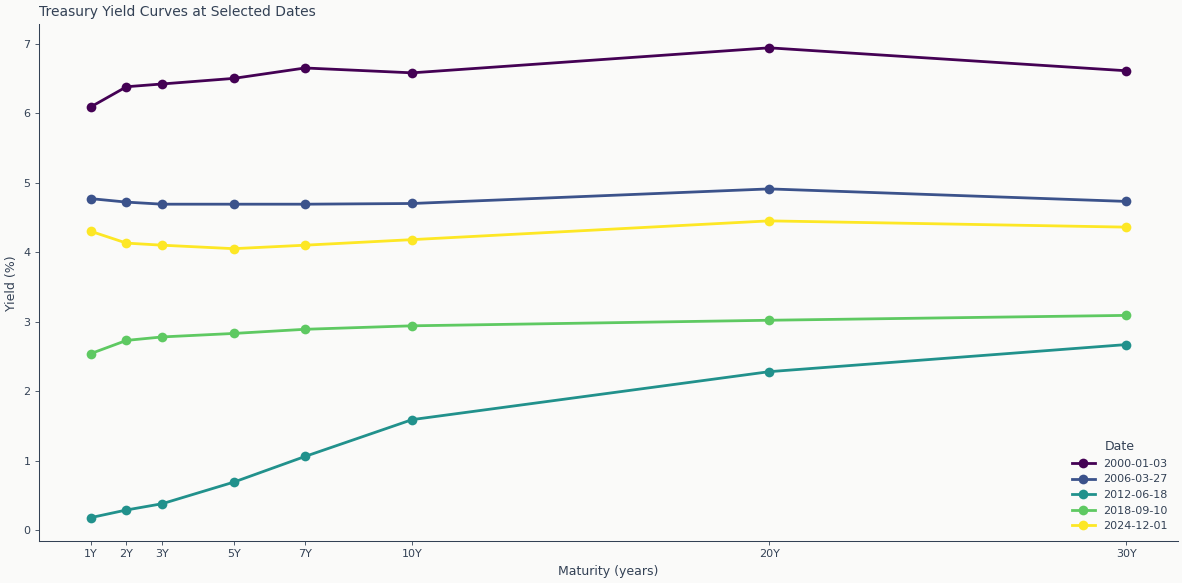

In [7]:
n_obs = len(yields)
sample_indices = [0, n_obs // 4, n_obs // 2, 3 * n_obs // 4, n_obs - 1]

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.colormaps["viridis"](np.linspace(0, 1, len(sample_indices)))
for idx, color in zip(sample_indices, colors, strict=False):
    row = yields.row(idx, named=True)
    curve = [row[c] for c in yield_names]
    label = str(np.datetime_as_string(timestamps[idx], unit="D"))
    ax.plot(
        MATURITIES_YEARS,
        curve,
        marker="o",
        color=color,
        label=label,
        linewidth=2,
        markersize=7,
    )

ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield (%)")
ax.set_title("Treasury Yield Curves at Selected Dates")
ax.set_xticks(MATURITIES_YEARS)
ax.set_xticklabels(MATURITY_LABELS)
ax.legend(title="Date", loc="best")


fig.tight_layout()
fig.show()

## 4. Yield Changes for PCA

PCA is typically applied to yield *changes* rather than levels, as changes
are more stationary and capture the dynamics we want to model.

In [8]:
yield_changes = yields.with_columns(pl.col(c).diff() for c in yield_names).drop_nulls()

change_timestamps = yield_changes["timestamp"].to_numpy()

In [9]:
# Yield change statistics (in basis points)
yield_changes.select(yield_names).describe()

statistic,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",9099.0,9099.0,9099.0,9099.0,9099.0,9099.0,9099.0,9099.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",-0.000197,-0.000247,-0.000255,-0.000269,-0.00028,-0.000264,-0.000274,-0.000247
"""std""",0.03479,0.045346,0.048161,0.050676,0.05091,0.048382,0.045898,0.044352
"""min""",-0.6,-0.57,-0.5,-0.46,-0.53,-0.51,-0.34,-0.33
"""25%""",-0.01,-0.01,-0.01,-0.02,-0.02,-0.02,-0.02,-0.02
"""50%""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""75%""",0.01,0.01,0.01,0.02,0.02,0.02,0.02,0.01
"""max""",0.52,0.38,0.37,0.34,0.3,0.29,0.35,0.29


We standardize yield changes before PCA (correlation-matrix PCA). This
equalizes the influence of each maturity regardless of its volatility level.
Some practitioners apply PCA to the covariance matrix directly when
maturity-level variance differences are economically meaningful — for example,
to let the volatile short end dominate the first component. With standardization,
each maturity contributes equally to the factor structure.

In [10]:
scaler = StandardScaler()
changes_np = yield_changes.select(yield_names).to_numpy()
changes_scaled = scaler.fit_transform(changes_np)

## 5. PCA on Yield Changes

PCA decomposes yield changes into orthogonal factors:

$$\Delta y_i = \beta_{i,1} f_1 + \beta_{i,2} f_2 + \beta_{i,3} f_3 + \epsilon_i$$

where $f_k$ are the principal component scores and $\beta_{i,k}$ are the loadings.
With eight maturities, we expect the first three components to reproduce the
classical Litterman–Scheinkman (1991) Level / Slope / Curvature pattern.

In [11]:
# svd_solver='full' is default for small matrices; explicit for clarity
pca = PCA(svd_solver="full")
pca.fit(changes_scaled)

var_explained = pca.explained_variance_ratio_
cumvar_explained = np.cumsum(var_explained)

n_meaningful = 3
loadings = pca.components_[:n_meaningful].copy()  # numpy array (n_meaningful x n_rates)
loading_names = ["PC1 (Level)", "PC2 (Slope)", "PC3 (Curvature)"]
scores_np = pca.transform(changes_scaled)

# PCA component signs are arbitrary — flip so each PC's economic interpretation
# matches its name:
#   Level: all-positive loadings (parallel shift up)
#   Slope: long-end positive, short-end negative (positive PC2 = steepening)
#   Curvature: middle of curve positive (butterfly upward)
signs = np.ones(n_meaningful)
if loadings[0].mean() < 0:
    signs[0] = -1.0
if loadings[1, 0] > loadings[1, -1]:
    signs[1] = -1.0
mid_idx = len(yield_names) // 2
if loadings[2, mid_idx] < 0:
    signs[2] = -1.0
loadings = loadings * signs[:, None]
scores_np[:, :n_meaningful] = scores_np[:, :n_meaningful] * signs

# Store key statistics
pc1_variance = var_explained[0] * 100
pc2_variance = var_explained[1] * 100
pc3_variance = var_explained[2] * 100
top3_cumvar = cumvar_explained[2] * 100

In [12]:
# Variance decomposition
pl.DataFrame(
    {
        "Component": [f"PC{i + 1}" for i in range(len(var_explained))],
        "Variance Explained (%)": (var_explained * 100).round(2),
        "Cumulative (%)": (cumvar_explained * 100).round(2),
    }
)

Component,Variance Explained (%),Cumulative (%)
str,f64,f64
"""PC1""",82.32,82.32
"""PC2""",12.32,94.64
"""PC3""",3.14,97.79
"""PC4""",1.0,98.79
"""PC5""",0.45,99.23
"""PC6""",0.34,99.57
"""PC7""",0.24,99.82
"""PC8""",0.18,100.0


**Interpretation**: PC1 explains the bulk of the variance, PC2 captures a
steepening/flattening dimension orthogonal to it, and PC3 captures a
middle-vs-ends curvature twist. Together the three components account for
essentially all of the daily-change variance — confirming the classical
Litterman–Scheinkman finding that the yield curve is effectively
three-dimensional. The loadings below establish the economic interpretation
of each factor.

In [13]:
# Factor loadings table
pl.DataFrame(
    {"Component": loading_names}
    | {name: loadings[:, i].round(3) for i, name in enumerate(yield_names)}
)

Component,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
str,f64,f64,f64,f64,f64,f64,f64,f64
"""PC1 (Level)""",0.283,0.346,0.366,0.381,0.381,0.375,0.352,0.333
"""PC2 (Slope)""",-0.585,-0.398,-0.263,-0.046,0.106,0.227,0.393,0.459
"""PC3 (Curvature)""",-0.723,0.241,0.33,0.3,0.187,0.039,-0.216,-0.371


## 6. Factor Loadings (Figure 14.4)

The loadings reveal how each factor distributes across maturities. With a
dense maturity grid spanning 1Y to 30Y, the classical Level / Slope / Curvature
pattern emerges in the first three components.

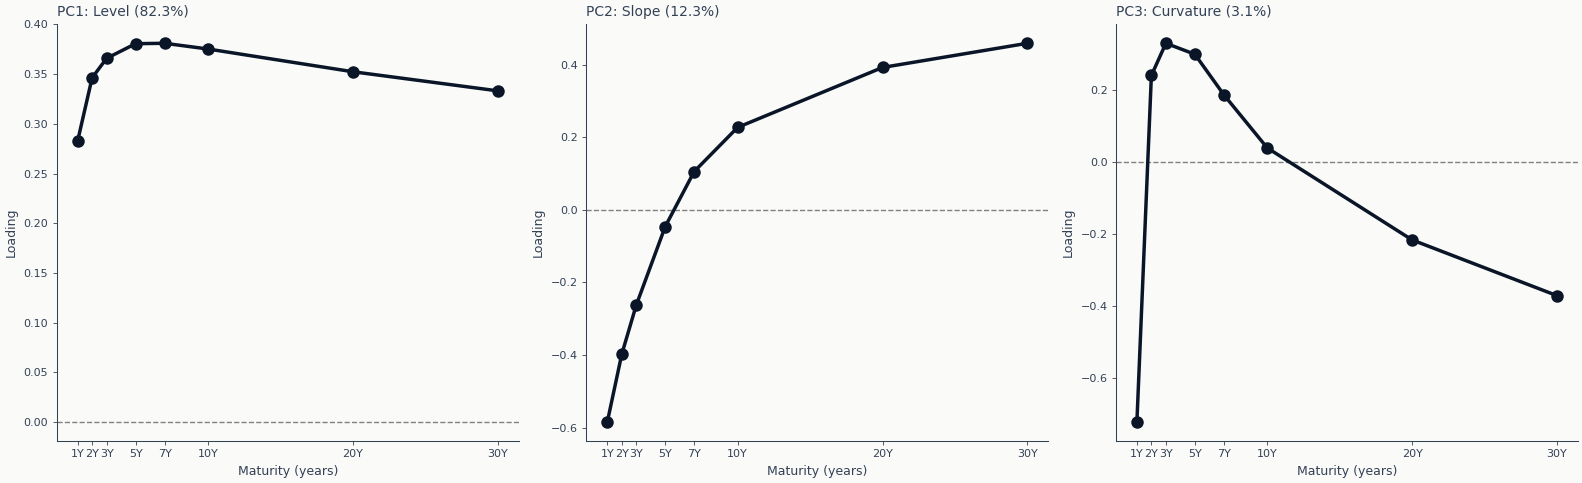

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

titles = [
    f"PC1: Level ({pc1_variance:.1f}%)",
    f"PC2: Slope ({pc2_variance:.1f}%)",
    f"PC3: Curvature ({pc3_variance:.1f}%)",
]

for i, (ax, title) in enumerate(zip(axes, titles, strict=False)):
    loading = loadings[i]

    ax.axhline(y=0, color="gray", linestyle="--", linewidth=1)
    ax.plot(MATURITIES_YEARS, loading, marker="o", linewidth=2.5, markersize=9)

    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Loading")
    ax.set_title(title)
    ax.set_xticks(MATURITIES_YEARS)
    ax.set_xticklabels(MATURITY_LABELS)


fig.tight_layout()
fig.show()

In [15]:
# Persist the loading profiles so they can be re-rendered at print resolution
# without re-fitting the PCA. Saved as a portable .npz alongside the notebook's
# other yield-curve artifacts.
artifact_dir = Path("output/yield_curve_decomposition")
artifact_dir.mkdir(parents=True, exist_ok=True)
np.savez(
    artifact_dir / "factor_loadings.npz",
    maturities_years=np.asarray(MATURITIES_YEARS),
    maturity_labels=np.asarray(MATURITY_LABELS),
    loadings=loadings,
    variance_explained_pct=np.asarray([pc1_variance, pc2_variance, pc3_variance]),
    component_names=np.asarray(["Level", "Slope", "Curvature"]),
)

**PC1 (Level)**: Approximately equal positive loadings across all maturities —
a near-parallel shift of the entire curve. This is the dominant mode of yield
variation, driven by changes in inflation expectations and the overall level
of interest rates.

**PC2 (Slope)**: Monotonically increasing loadings from short to long
maturities (negative at the short end, positive at the long end). Positive
PC2 corresponds to *steepening* (long rates rise more than short rates).
Slope variation reflects business-cycle dynamics: the curve typically flattens
during tightening cycles and steepens during easing.

**PC3 (Curvature)**: Opposite signs on the middle of the curve versus the
ends — a "butterfly" twist where intermediate maturities move differently
from the short and long ends. This factor reflects nuances in term-premium
pricing and convexity effects.

## 7. Scree Plot

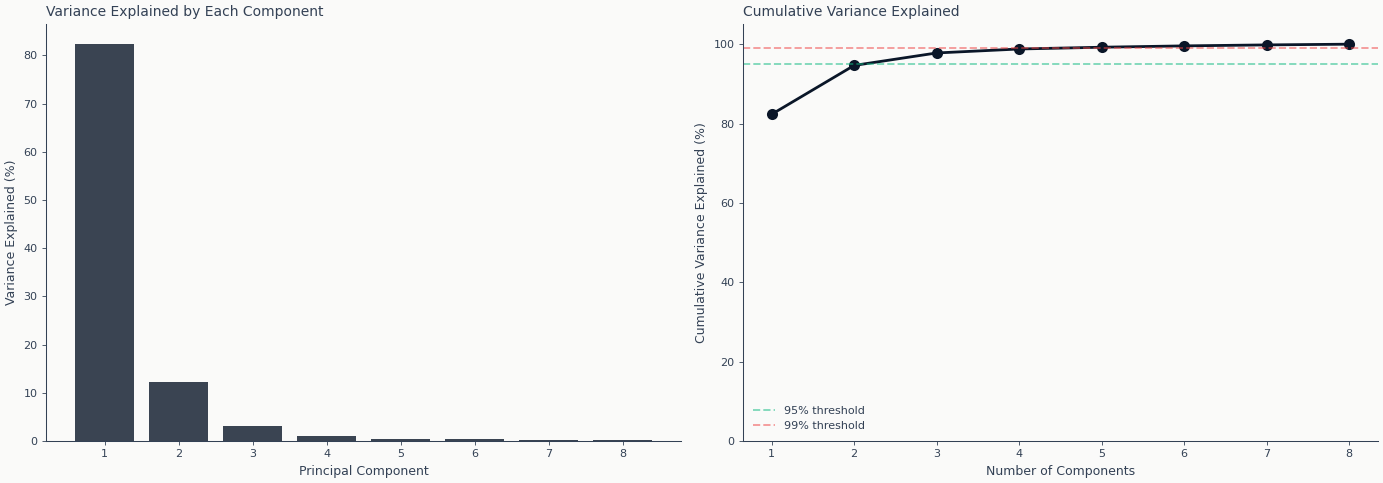

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_components = len(var_explained)

# Individual variance
ax1 = axes[0]
ax1.bar(range(1, n_components + 1), var_explained * 100, alpha=0.8)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Variance Explained (%)")
ax1.set_title("Variance Explained by Each Component")
ax1.set_xticks(range(1, n_components + 1))

# Cumulative variance
ax2 = axes[1]
ax2.plot(
    range(1, n_components + 1),
    cumvar_explained * 100,
    marker="o",
    linewidth=2,
    markersize=8,
)
ax2.axhline(y=95, color=COLORS["positive"], linestyle="--", alpha=0.5, label="95% threshold")
ax2.axhline(y=99, color=COLORS["negative"], linestyle="--", alpha=0.5, label="99% threshold")
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Variance Explained (%)")
ax2.set_title("Cumulative Variance Explained")
ax2.set_xticks(range(1, n_components + 1))
ax2.set_ylim(0, 105)
ax2.legend()

fig.tight_layout()
fig.show()

The first component dominates, three components capture essentially all of
the variance, and components beyond PC3 add negligible explanatory power.
The yield curve's effective dimension is three — exactly the Level / Slope /
Curvature structure documented in Litterman & Scheinkman (1991) for the US
Treasury market.

## 8. Factor Time Series

In [17]:
factor_names = ["Level", "Slope", "Curvature"]
scores_for_plot = scores_np[:, :n_meaningful]

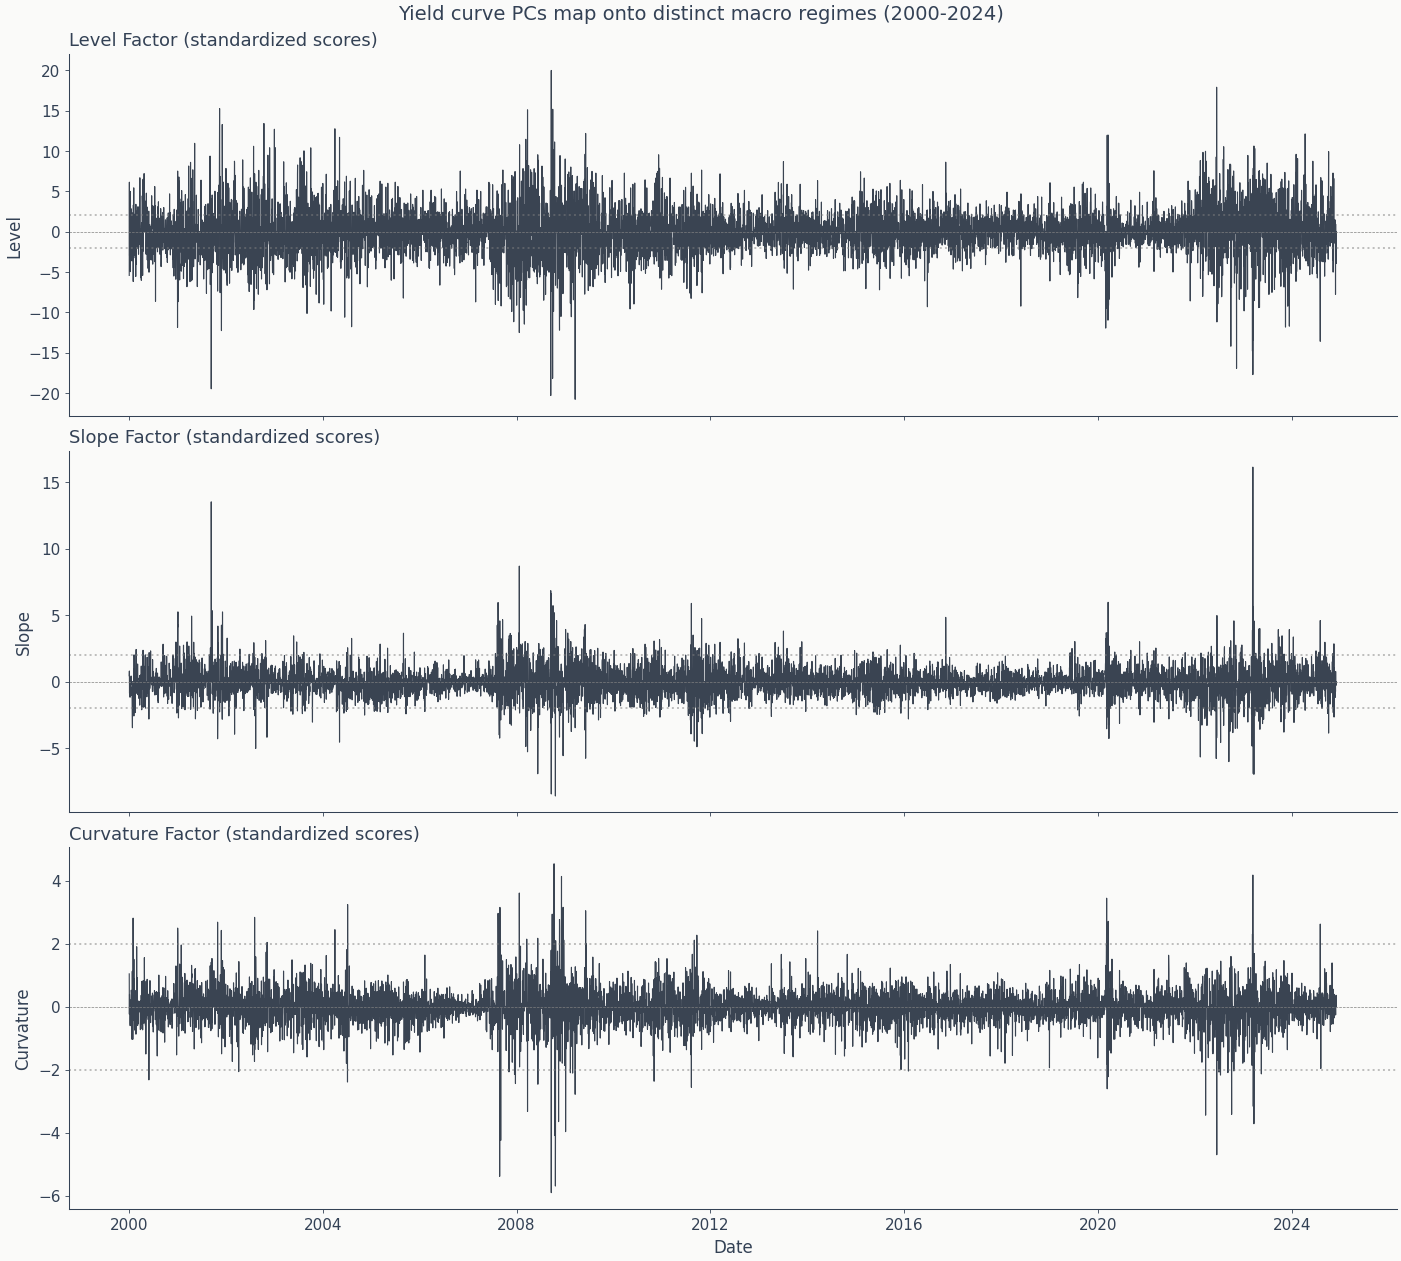

In [18]:
fig, axes = plt.subplots(
    n_meaningful, 1, figsize=(14, 4.2 * n_meaningful), sharex=True, constrained_layout=True
)

for i, (ax, name) in enumerate(zip(axes, factor_names, strict=False)):
    ax.plot(change_timestamps, scores_for_plot[:, i], linewidth=0.8, alpha=0.8)
    ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.5)
    ax.set_ylabel(name, fontsize=12)
    ax.set_title(f"{name} Factor (standardized scores)", fontsize=13)
    ax.tick_params(axis="both", labelsize=11)

    # ±2σ bands
    ax.axhline(y=2, color="gray", linestyle=":", alpha=0.5)
    ax.axhline(y=-2, color="gray", linestyle=":", alpha=0.5)

axes[-1].set_xlabel("Date", fontsize=12)
fig.suptitle("Yield curve PCs map onto distinct macro regimes (2000-2024)", fontsize=14)
fig.show()

The Level factor shows the largest cumulative moves during major rate
regimes — the secular post-2008 decline, the 2020 emergency cuts, and the
2022 tightening shock. The Slope factor captures business-cycle dynamics,
with sustained negative readings during curve inversions that often precede
recessions (2007, 2019, 2022–23). The Curvature factor moves at higher
frequency and reflects term-premium adjustments and convexity dynamics.

## 9. Reconstruction Quality

The reconstructed yield changes use the first $K$ components:

$$\Delta \hat{y} = F_K \Lambda_K^T$$

where $F_K$ is the $(T \times K)$ score matrix and $\Lambda_K$ the $(K \times N)$ loading matrix.
With three factors explaining essentially all of the variance, reconstructed
changes should closely track actuals across every maturity.

In [19]:
# Reconstruct yield changes from the first 3 PCs
n_reconstruct = 3
# Use the SIGN-CORRECTED scores and loadings consistently
scores_3pc = scores_np[:, :n_reconstruct]
reconstructed_scaled = scores_3pc @ loadings[:n_reconstruct]
reconstructed_np = scaler.inverse_transform(reconstructed_scaled)

# Reconstruction RMSE per maturity (in basis points)
actual_std_bps = changes_np.std(axis=0) * 100
rmse_bps = np.sqrt(((changes_np - reconstructed_np) ** 2).mean(axis=0)) * 100

pl.DataFrame(
    {
        "Maturity": yield_names,
        "Actual Std (bps)": actual_std_bps.round(2),
        "Reconstruction RMSE (bps)": rmse_bps.round(2),
        "RMSE / Std (%)": (rmse_bps / actual_std_bps * 100).round(2),
    }
)

Maturity,Actual Std (bps),Reconstruction RMSE (bps),RMSE / Std (%)
str,f64,f64,f64
"""1Y""",3.48,0.23,6.61
"""2Y""",4.53,0.9,19.79
"""3Y""",4.82,0.73,15.09
"""5Y""",5.07,0.74,14.54
"""7Y""",5.09,0.79,15.47
"""10Y""",4.84,0.7,14.52
"""20Y""",4.59,0.62,13.55
"""30Y""",4.43,0.72,16.19


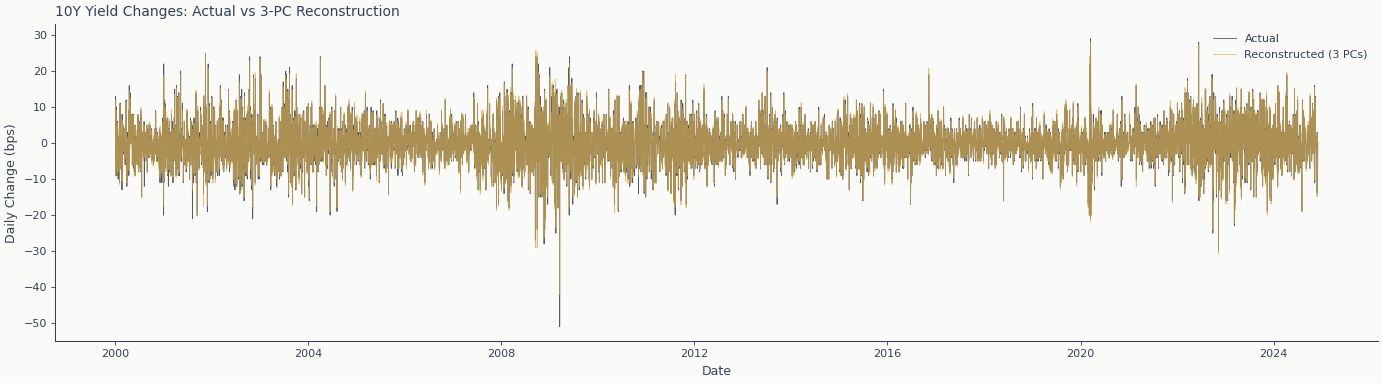

In [20]:
# Overlay actual vs reconstructed for the 10Y maturity
target = "10Y"
target_idx = yield_names.index(target)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(
    change_timestamps, changes_np[:, target_idx] * 100, linewidth=0.6, alpha=0.7, label="Actual"
)
ax.plot(
    change_timestamps,
    reconstructed_np[:, target_idx] * 100,
    linewidth=0.6,
    alpha=0.7,
    label=f"Reconstructed ({n_reconstruct} PCs)",
)
ax.set_xlabel("Date")
ax.set_ylabel("Daily Change (bps)")
ax.set_title(f"{target} Yield Changes: Actual vs {n_reconstruct}-PC Reconstruction")
ax.legend()

fig.tight_layout()
fig.show()

**Finding**: Three PCs reconstruct every maturity's daily changes with RMSE
between roughly 7% and 20% of the maturity's standard deviation (the 1Y is
the tightest at ~7%, most maturities fall in the 13–20% range). The
reconstructed series is visually indistinguishable from the actual at the 10Y
point. The remaining
residual reflects measurement noise and idiosyncratic moves at specific
maturities — not a missing systematic factor.

## 10. Practical Application: Generalized Duration

The low-dimensional structure enables efficient hedging. Rather than managing
exposure to dozens of individual bonds, a portfolio manager neutralizes three
factor exposures — level, slope, and curvature sensitivity:

1. **Level Duration**: Sensitivity to parallel shifts (traditional DV01)
2. **Slope Duration**: Sensitivity to curve steepening/flattening
3. **Curvature Duration**: Sensitivity to butterfly twists

This "generalized duration" framework enables more precise hedging using
liquid instruments (Treasury futures, interest rate swaps) that target
specific yield curve movements. See Chapter 14, Section 14.4 for the full
hedging discussion.

## 11. Summary Statistics

In [21]:
pl.DataFrame(
    {
        "Factor": ["Level (PC1)", "Slope (PC2)", "Curvature (PC3)", "Total (3 PCs)"],
        "Variance Explained (%)": [
            round(pc1_variance, 1),
            round(pc2_variance, 1),
            round(pc3_variance, 1),
            round(top3_cumvar, 1),
        ],
        "Pattern": [
            "Parallel shift across all maturities",
            "Short vs long end (steepening/flattening)",
            "Middle vs ends (butterfly twist)",
            "—",
        ],
        "Economic Driver": [
            "Inflation expectations, overall rate level",
            "Business cycle, monetary policy stance",
            "Term premium, convexity",
            "—",
        ],
    }
)

Factor,Variance Explained (%),Pattern,Economic Driver
str,f64,str,str
"""Level (PC1)""",82.3,"""Parallel shift across all matu…","""Inflation expectations, overal…"
"""Slope (PC2)""",12.3,"""Short vs long end (steepening/…","""Business cycle, monetary polic…"
"""Curvature (PC3)""",3.1,"""Middle vs ends (butterfly twis…","""Term premium, convexity"""
"""Total (3 PCs)""",97.8,"""—""","""—"""


## Key Takeaways

1. **Three-dimensional yield curve**: PC1 (Level), PC2 (Slope), and PC3
   (Curvature) together explain effectively all of the variance in daily
   yield-change cross-sections — a ~82/12/3 % split in this sample, the same
   Level/Slope/Curvature structure documented in Litterman & Scheinkman
   (1991). The yield curve's effective dimension is three, not eight.

2. **Low-dimensional macro drivers**: The yield curve's compressibility
   reflects that its underlying drivers (inflation expectations, business
   cycle, term premium) are themselves low-dimensional — in sharp contrast
   to equities, where thousands of idiosyncratic factors operate alongside
   a smaller systematic core.

3. **Practical hedging**: Factor-based duration management neutralizes
   exposure to Level, Slope, and Curvature using a small set of liquid
   instruments (Treasury futures, swaps), rather than tracking dozens of
   individual bonds. The same three-factor structure underpins risk
   decomposition for fixed-income portfolios and structured-product books.

**Next**: See [`04_ipca`](04_ipca.ipynb) for time-varying factor models that extend PCA
by conditioning on observable characteristics.